# Student Dropout Prediction System — Exploratory Data Analysis (EDA)

Phase 2: Exploratory Data Analysis (EDA)

In this phase, we explore and understand the dataset before applying machine learning models.  
The objective of Exploratory Data Analysis (EDA) is to uncover patterns, relationships, and potential issues in the data.

Key goals of this phase include:

- Understanding the dataset structure
- Analyzing the target variable distribution
- Investigating relationships between features and dropout
- Identifying correlations between variables
- Checking for missing values
- Preparing the dataset for modeling

## Importing Required Libraries

The following Python libraries are used for data analysis and visualization:

- **pandas** for data manipulation
- **numpy** for numerical computations
- **matplotlib** for data visualization
- **seaborn** for advanced statistical visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

## Previewing the Dataset

To understand the structure of the dataset, we display the first few rows.  
This helps verify that the data has been loaded correctly and provides an overview of the available features.

In [2]:
df = pd.read_csv("../data/student_dataset.csv", sep=";")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Dataset Dimensions

The dataset shape provides information about:

- The number of observations (students)
- The number of variables (features)

This helps us understand the scale of the dataset.

In [3]:
df.shape

(4424, 37)

In [4]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

## Target Variable Distribution

The original dataset contains three student outcomes:

- Graduate
- Dropout
- Enrolled

Understanding the distribution of these outcomes helps determine whether the dataset is balanced and provides insight into overall student success and dropout patterns.

In [5]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

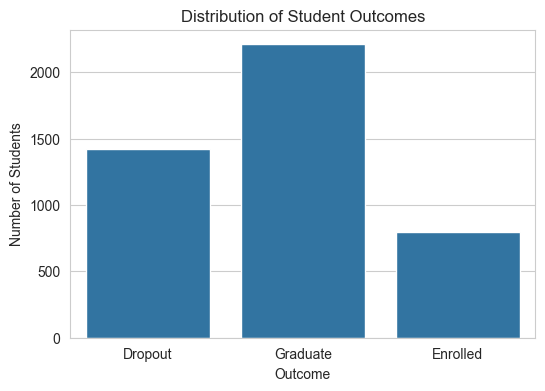

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Target")

plt.title("Distribution of Student Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")

plt.show()

In [7]:
df["Dropout_Binary"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

df[["Target", "Dropout_Binary"]].head()

,Target,Dropout_Binary
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0


In [8]:
df["Dropout_Binary"].value_counts()

Dropout_Binary
0    3003
1    1421
Name: count, dtype: int64

## Correlation Analysis

A correlation heatmap is used to examine relationships between numerical variables.

This helps identify:

- Features strongly associated with student dropout
- Redundant features
- Potential predictors for machine learning models

/Users/hrishikeshshetty/Github Projects/student-dropout-prediction/venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.draw()
/Users/hrishikeshshetty/Github Projects/student-dropout-prediction/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


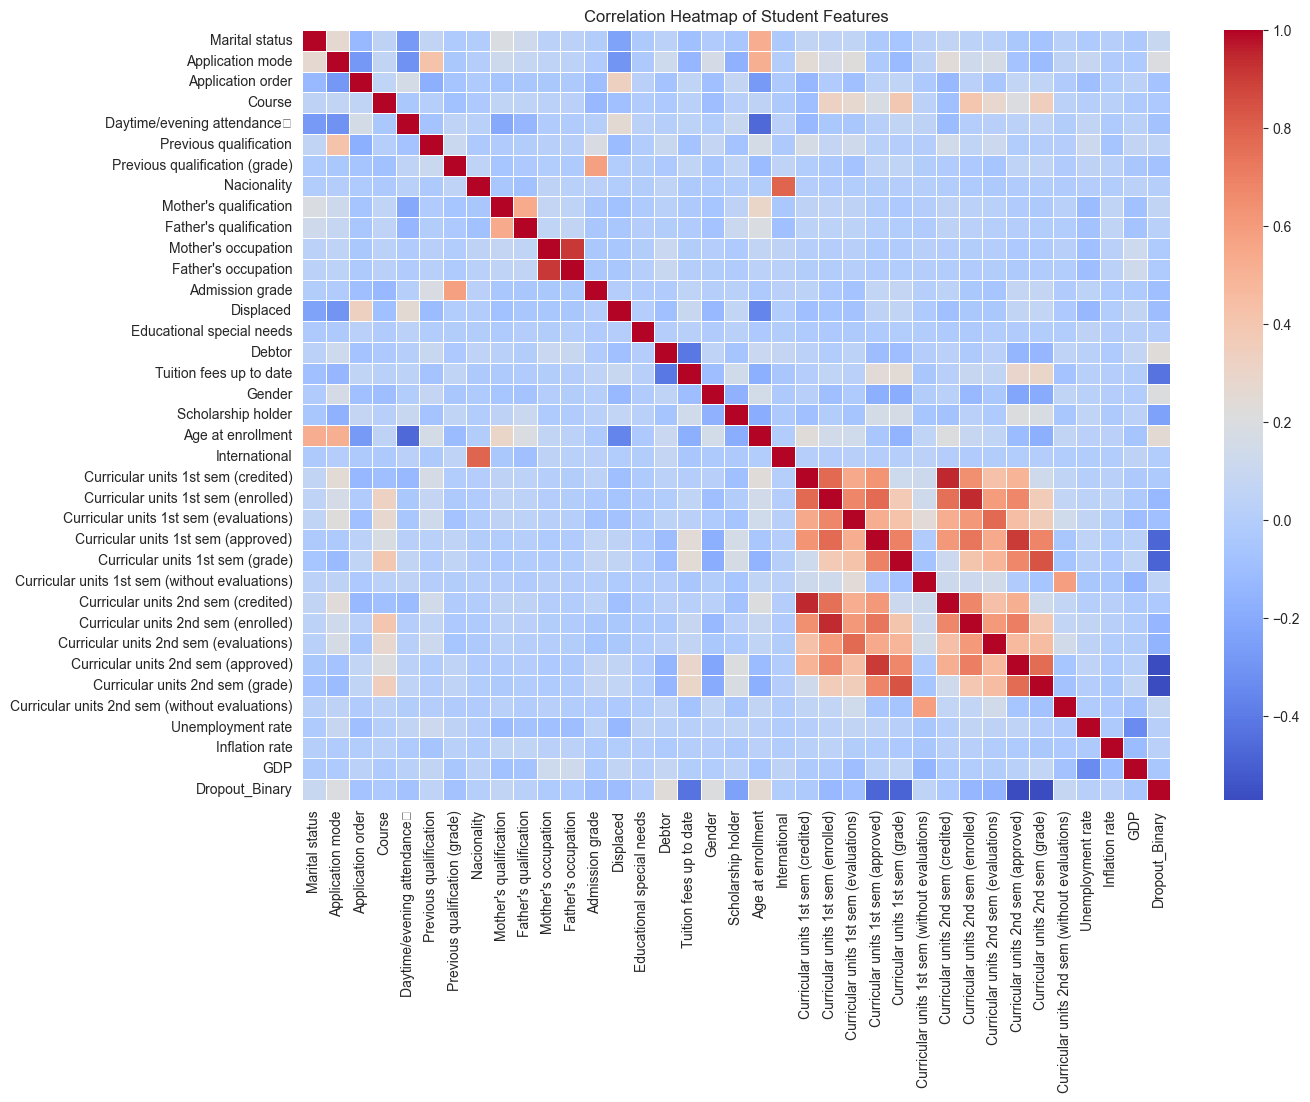

In [9]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Student Features")

plt.show()

In [10]:
corr["Dropout_Binary"].sort_values(ascending=False)

Dropout_Binary                                    1.000000
Age at enrollment                                 0.254215
Debtor                                            0.229407
Gender                                            0.203983
Application mode                                  0.198458
Marital status                                    0.093712
Curricular units 2nd sem (without evaluations)    0.079901
Mother's qualification                            0.064958
Curricular units 1st sem (without evaluations)    0.054230
Previous qualification                            0.049379
Inflation rate                                    0.027826
Father's qualification                            0.018295
Unemployment rate                                 0.012980
Nacionality                                       0.008346
Educational special needs                         0.002806
International                                    -0.010360
Mother's occupation                              -0.0219

## Academic Performance vs Student Dropout

This visualization explores the relationship between students' academic performance and dropout behavior. Based on the correlation analysis, semester grades show the strongest relationship with dropout probability.

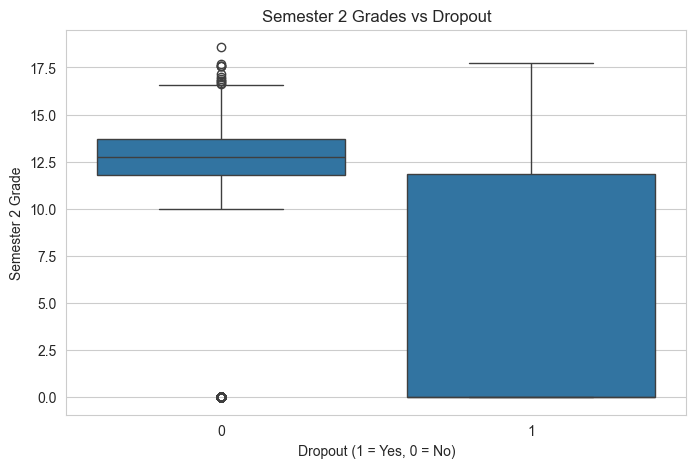

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Dropout_Binary",
    y="Curricular units 2nd sem (grade)"
)

plt.title("Semester 2 Grades vs Dropout")
plt.xlabel("Dropout (1 = Yes, 0 = No)")
plt.ylabel("Semester 2 Grade")

plt.show()

The boxplot shows a clear relationship between academic performance and dropout. Students who dropped out tend to have significantly lower Semester 2 grades compared to students who remained enrolled or graduated. This suggests that academic performance is a strong predictor of student retention.

## Tuition Fee Status vs Dropout

Financial factors may influence student persistence. This visualization examines whether students who are not up to date on tuition payments are more likely to drop out.

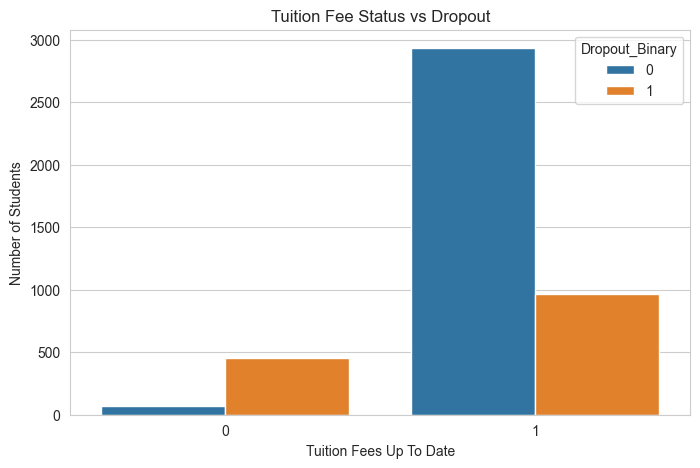

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Tuition fees up to date",
    hue="Dropout_Binary"
)

plt.title("Tuition Fee Status vs Dropout")
plt.xlabel("Tuition Fees Up To Date")
plt.ylabel("Number of Students")

plt.show()

The analysis shows that students who are not up to date with their tuition payments have a significantly higher dropout rate compared to students who maintain their tuition payments. This suggests that financial stability plays an important role in student retention.

## Age at Enrollment vs Dropout
This analysis investigates whether age at enrollment influences the likelihood of student dropout.

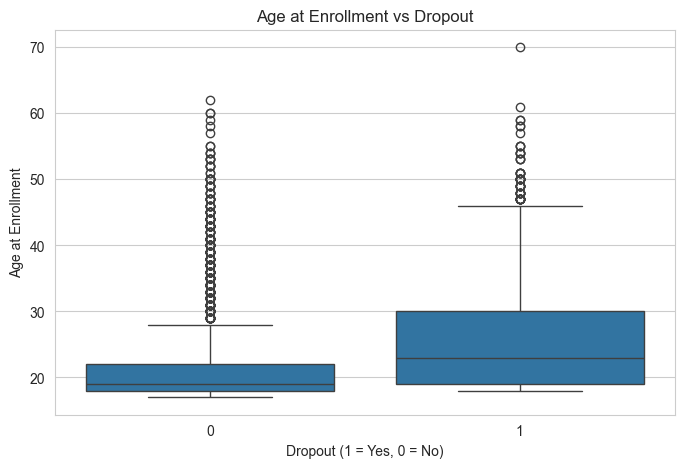

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Dropout_Binary",
    y="Age at enrollment"
)

plt.title("Age at Enrollment vs Dropout")
plt.xlabel("Dropout (1 = Yes, 0 = No)")
plt.ylabel("Age at Enrollment")

plt.show()

The analysis indicates that students who enroll at an older age tend to have a higher dropout rate compared to younger students. This may reflect additional responsibilities such as employment or financial obligations that affect persistence in higher education.

## Checking for Missing Values

Before building machine learning models, it is important to verify whether the dataset contains missing values that may require preprocessing or cleaning.

In [14]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

## Feature and Target Separation

For machine learning modeling, the dataset is separated into:

- **Features (X)**: All independent variables used for prediction
- **Target (y)**: The dropout indicator

In [15]:
X = df.drop(columns=["Target", "Dropout_Binary"])
y = df["Dropout_Binary"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4424, 36)
Target shape: (4424,)
